# A Jupyter notebook to generate a NetCDF file of precipitation and wind data within 1000 km of storm trajectories.

## Import Required Libraries
Import libraries such as xarray, pandas, numpy, matplotlib, and tqdm.

In [1]:
# Import Required Libraries
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from braceexpand import braceexpand
import calendar
import sys
import os
from ETC_tools import open_files
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Define Helper Functions
Define functions like `braced_glob` for file handling and `haversine` for distance calculations.

In [6]:
# Define Helper Functions
def braced_glob(path):
    """
    Expand brace patterns in file paths and return a list of matching files.
    """
    files = []
    for expanded_path in braceexpand(path):
        files.extend(glob(expanded_path))
    return files

def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points on the Earth (specified in decimal degrees).
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

## Load Storm Data
Read the storm trajectory data from the `df` file and filter it for the desired year.

In [30]:
# Load Storm Data
iyear = 2019
imonth = '11'
sim = 'ERA5'
extreme = True
last_day = calendar.monthrange(iyear, int(imonth))[1]

if sim != 'ERA5' and iyear == 1979 and imonth == '09':
    start = f"{iyear}-{imonth}-01 01:00:00"
else:
    start = f"{iyear}-{imonth}-01 00:00:00"
end = f"{iyear}-{imonth}-{last_day} 23:00:00"

expected_time = pd.date_range(
    start=start,
    end=end,
    freq="h"
).to_numpy()

In [31]:
%%time
if extreme == True:
    df, EETC_dict = open_files(sim, metric='diff', wetdays=False, future=True, original_selection=False, period_filtering=False)

    quantiles = [0.98, 0.99, 0.995, 0.999]

    EETCs_list = {'precip': {'0.98': [], '0.99': [], '0.995': [], '0.999': []},
          'wind': {'0.98': [], '0.99': [], '0.995': [], '0.999': []}}

    for storm in EETC_dict:
        for quantile in quantiles:
            if (
                EETC_dict[storm]['cum_precip'].sel(quantile=quantile).values > 1 or #!=0 if test='diff'!
                EETC_dict[storm]['cum_avg_precip'].sel(quantile=quantile).values > 1
            ):
                EETCs_list['precip'][str(quantile)].append(storm)
            if (
                EETC_dict[storm]['cum_wind'].sel(quantile=quantile).values > 1 or
                EETC_dict[storm]['cum_avg_wind'].sel(quantile=quantile).values > 1 or
                EETC_dict[storm]['SSI'].sel(quantile=quantile).values != 0 #always != 0
            ):
                EETCs_list['wind'][str(quantile)].append(storm)
else:
    df, _ = open_files(sim, metric='diff', wetdays=False, future=True, original_selection=False, period_filtering=False)
    
df = df[df['date'].dt.year == iyear]

Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_ERA5_Quebec_1005hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with False period filtering
CPU times: user 39.1 s, sys: 4.54 s, total: 43.6 s
Wall time: 44.3 s


## Load Precipitation and Wind Data
Load precipitation and wind datasets using xarray and preprocess them (e.g., unit conversions, time slicing).

In [32]:
if sim == 'ERA5':
    # filenames_precip = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR/era5_tp_CORDEX_NA_1979-2023.zarr'
    # ds_precip = xr.open_zarr(filenames_precip)
    # ds_precip = ds_precip.sel(time=slice(f'{iyear}-{imonth}-01', f'{iyear}-{imonth}-{last_day}'))
    input_dir = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR'
    filenames_precip = sorted(glob(f'{input_dir}/{iyear}/{imonth}/*.nc4'))
    ds_precip = xr.open_mfdataset(filenames_precip, combine='by_coords')
    ds_precip = ds_precip.sel(time=slice(f'{iyear}-{imonth}-01', f'{iyear}-{imonth}-{last_day}'))
    ds_precip = ds_precip.assign_coords({'longitude': (((ds_precip['longitude'] + 180) % 360) - 180)})
    ds_precip = ds_precip.sortby(ds_precip['longitude'])
    mask = xr.open_dataarray('/home/vdemeyer/projects/rrg-gachon/vdemeyer/MASK/mask_CRCM6_grid_for_ERA5.nc')
    ds_precip = ds_precip.where(mask, drop=True)
    ds_precip = ds_precip.rename({'tp': 'pr'})
    ds_precip['pr'] = ds_precip.pr * 1000.
    ds_precip = ds_precip.chunk({'latitude': 50, 'longitude': 50, 'time': 25})
else:
    filenames_precip = braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/PR/pr_{sim.lower()}_{iyear}{imonth}_se.nc')
    ds_precip = xr.open_mfdataset(filenames_precip)
    ds_precip['time'] = ds_precip['time'].dt.floor('h')
    ds_precip['pr'] = ds_precip.pr * 3600.
    if iyear == 1979 and imonth == '09':
        expected_start_time = '1979-09-01 01:00:00'
        ds_precip = ds_precip.isel(time=slice(1, None))
    else:
        expected_start_time = f'{iyear}-{imonth}-01 00:00:00'
    actual_start_time_precip = ds_precip['time'][0].dt.strftime('%Y-%m-%d %H:%M:%S').values
    if actual_start_time_precip != expected_start_time:
        raise ValueError(f"The first time coordinate for precipitation is not {expected_start_time} but {actual_start_time_precip}")
    ds_precip = ds_precip.chunk({'rlat': 50, 'rlon': 50, 'time': 25})

if not np.array_equal(ds_precip['time'].to_numpy(), expected_time):
    raise ValueError(f"The time coordinates for precipitation is wrong for {iyear}-{imonth}")

ds_precip = ds_precip.compute()

if hasattr(ds_precip, 'lon'):
    var_lon, var_lat = 'lon', 'lat'
elif hasattr(ds_precip, 'longitude'):
    var_lon, var_lat = 'longitude', 'latitude'
else:
    raise AttributeError(f'No dimension lon or longitude / lat or latitude in {ds_precip}')

### WIND
if sim == 'ERA5':
    # filenames_wind = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/WIND/Magnitude/era5_wind10_CORDEX_NA_1979-2023.zarr'
    # ds_wind = xr.open_zarr(filenames_wind)
    input_dir = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/WIND/Magnitude'
    filenames_wind = sorted(glob(f'{input_dir}/{iyear}/{imonth}/*.nc4'))
    ds_wind = xr.open_mfdataset(filenames_wind, combine='by_coords')
    ds_wind = ds_wind.sel(time=slice(f'{iyear}-{imonth}-01', f'{iyear}-{imonth}-{last_day}'))
    ds_wind = ds_wind.assign_coords({'longitude': (((ds_wind['longitude'] + 180) % 360) - 180)})
    ds_wind = ds_wind.sortby(ds_wind['longitude'])
    ds_wind = ds_wind.where(mask, drop=True)
    ds_wind = ds_wind.chunk({'latitude': 50, 'longitude': 50, 'time': 25})
else:
    filenames_wind = braced_glob(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/{sim}/WIND/wind10_{sim.lower()}_{iyear}{imonth}_se.nc')
    ds_wind = xr.open_mfdataset(filenames_wind)
    ds_wind['time'] = ds_wind['time'].dt.round('h')
    if sim in ['UBG', 'UBH', 'UBI'] and iyear == 2100 and imonth == '12':
        ds_wind = ds_wind.isel(time=slice(0, -1)) #There is one hour of data on 2100-12-31T00:00:00.000000000 that does not exist in the precipitation file
    actual_start_time_wind = ds_wind['time'][0].dt.strftime('%Y-%m-%d %H:%M:%S').values
    if actual_start_time_wind != expected_start_time:
        raise ValueError(f"The first time coordinate for wind is not {expected_start_time} but {actual_start_time_wind}")
    ds_wind = ds_wind.chunk({'rlat': 50, 'rlon': 50, 'time': 25})

if not np.array_equal(ds_wind['time'].to_numpy(), expected_time):
    print(ds_wind['time'].to_numpy()[:10])
    print(expected_time[:10])
    raise ValueError(f"The time coordinates for wind is wrong for {iyear}-{imonth}")

ds_wind = ds_wind.compute()

## Filter Data Within 1000 km of Storm Trajectories
Iterate through storm trajectories, filter precipitation and wind data within 1000 km using the `haversine` function, and store the results.

Here is a cell with no loop on the time step

In [33]:
# %%time

# if sim == 'ERA5':
#     lon_2d, lat_2d = np.meshgrid(ds_precip[var_lon].values, ds_precip[var_lat].values)
#     if extreme == True:
#         shape_grid = xr.DataArray(np.expand_dims(lon_2d, axis=-1).repeat(len(quantiles), axis=-1), 
#                   dims=[var_lat, var_lon, 'quantile'], 
#                   coords={var_lon: ds_precip[var_lon], var_lat: ds_precip[var_lat], 'quantile': quantiles}) 
#     else:
#         shape_grid = xr.DataArray(lon_2d, dims=[var_lat, var_lon], coords={var_lon: ds_precip[var_lon], var_lat: ds_precip[var_lat]})
# else:
#     lon_2d = ds_precip[var_lon].values
#     lat_2d = ds_precip[var_lat].values
#     if extreme == True:
#         shape_grid = ds_precip[var_lon].expand_dims(quantile=quantiles)
#     else:
#         shape_grid = ds_precip[var_lon]
    
# itime = ds_precip['time'].values[100]

# storms_at_time = df[df['date'] == pd.Timestamp(itime)]

# if extreme == True:
    
#     precip_masks = []
#     wind_masks = []
    
#     for masks, EETC_key in zip([precip_masks, wind_masks], ['precip', 'wind']):
#         distances = xr.full_like(shape_grid, np.inf, dtype=float)
#         for quantile in quantiles:
#             filtered_storms = storms_at_time[storms_at_time['storm'].isin(EETCs_list[EETC_key][str(quantile)])]
#             if filtered_storms.empty:
#                 continue
#             storm_lons = filtered_storms['lon'].values
#             storm_lats = filtered_storms['lat'].values
#             for lon, lat in zip(storm_lons, storm_lats):
#                 distances.loc[dict(quantile=quantile)] = xr.ufuncs.minimum(distances.sel(quantile=quantile), haversine(lon_2d, lat_2d, lon, lat))
#             if EETC_key == 'precip':
#                 precip_mask = ds_precip.sel(time=itime).where(distances <= 1000, drop=False)
#             elif EETC_key == 'wind':
#                 wind_mask = ds_wind.sel(time=itime).where(distances <= 1000, drop=False)

# else:
#     storm_lons = storms_at_time['lon'].values
#     storm_lats = storms_at_time['lat'].values
#     distances = xr.full_like(shape_grid, np.inf, dtype=float)

#     for lon, lat in zip(storm_lons, storm_lats):
#         distances = xr.ufuncs.minimum(distances, haversine(lon_2d, lat_2d, lon, lat))

#     precip_mask = ds_precip.sel(time=itime).where(distances <= 1000, drop=False)
#     wind_mask = ds_wind.sel(time=itime).where(distances <= 1000, drop=False)
    
# precip_mask

Here is a cell with a loop on the time steps, the ## highlights the lines to save distances to plot later, but not done in the main script

In [34]:
%%time

if sim == 'ERA5':
    lon_2d, lat_2d = np.meshgrid(ds_precip[var_lon].values, ds_precip[var_lat].values)
    if extreme == True:
        shape_grid = xr.DataArray(np.expand_dims(lon_2d, axis=-1).repeat(len(quantiles), axis=-1), 
                  dims=[var_lat, var_lon, 'quantile'], 
                  coords={var_lon: ds_precip[var_lon], var_lat: ds_precip[var_lat], 'quantile': quantiles}) 
    else:
        shape_grid = xr.DataArray(lon_2d, dims=[var_lat, var_lon], coords={var_lon: ds_precip[var_lon], var_lat: ds_precip[var_lat]})
else:
    lon_2d = ds_precip[var_lon].values
    lat_2d = ds_precip[var_lat].values
    if extreme == True:
        shape_grid = ds_precip[var_lon].expand_dims(quantile=quantiles)
    else:
        shape_grid = ds_precip[var_lon]
    
# itime = ds_precip['time'].values[100]

filtered_precip_list = []
filtered_wind_list = []
filtered_distances_precip_list = []##
filtered_distances_wind_list = []##
        
for itime in tqdm(ds_precip['time'].values[25:26]):
    
    storms_at_time = df[df['date'] == pd.Timestamp(itime)]
    
    if storms_at_time.empty:
        if extreme == True:
            filtered_precip_list.append(xr.full_like(ds_precip.sel(time=itime).pr, np.nan).expand_dims(quantile=quantiles))
            filtered_wind_list.append(xr.full_like(ds_wind.sel(time=itime).surf_wind, np.nan).expand_dims(quantile=quantiles))
            filtered_distances_precip_list.append(xr.full_like(ds_wind.sel(time=itime).surf_wind, np.inf).expand_dims(quantile=quantiles))##
            filtered_distances_wind_list.append(xr.full_like(ds_wind.sel(time=itime).surf_wind, np.inf).expand_dims(quantile=quantiles))##
        else:
            filtered_precip_list.append(xr.full_like(ds_precip.sel(time=itime).pr, np.nan))
            filtered_wind_list.append(xr.full_like(ds_wind.sel(time=itime).surf_wind, np.nan))
        continue

    if extreme == True:
        
        for EETC_key in ['precip', 'wind']:
            distances = xr.full_like(shape_grid, np.inf, dtype=float)
            for quantile in quantiles:
                filtered_storms = storms_at_time[storms_at_time['storm'].isin(EETCs_list[EETC_key][str(quantile)])]
                if filtered_storms.empty:
                    continue
                storm_lons = filtered_storms['lon'].values
                storm_lats = filtered_storms['lat'].values
                for lon, lat in zip(storm_lons, storm_lats):
                    distances.loc[dict(quantile=quantile)] = xr.ufuncs.minimum(distances.sel(quantile=quantile), haversine(lon_2d, lat_2d, lon, lat))
            if EETC_key == 'precip':
                precip_mask = ds_precip.sel(time=itime).where(distances <= 1000, drop=False)
                filtered_precip_list.append(precip_mask.pr)
                filtered_distances_precip_list.append(distances)##
            elif EETC_key == 'wind':
                wind_mask = ds_wind.sel(time=itime).where(distances <= 1000, drop=False)
                filtered_wind_list.append(wind_mask.surf_wind)
                filtered_distances_wind_list.append(distances)##
                
        distances_precip = xr.Dataset({
            'distances_precip': xr.concat(
            [dist.expand_dims(time=[itime]) for dist, itime in zip(filtered_distances_precip_list, ds_precip['time'].values)],
            dim='time'
            )
        })##
        if sim == 'ERA5': distances_precip = distances_precip.where(mask, drop=True)##

        distances_wind = xr.Dataset({
            'distances_wind': xr.concat(
            [dist.expand_dims(time=[itime]) for dist, itime in zip(filtered_distances_wind_list, ds_precip['time'].values)],
            dim='time'
            )
        })##     
        if sim == 'ERA5': distances_wind = distances_wind.where(mask, drop=True)##

    else:
        storm_lons = storms_at_time['lon'].values
        storm_lats = storms_at_time['lat'].values
        distances = xr.full_like(shape_grid, np.inf, dtype=float)

        for lon, lat in zip(storm_lons, storm_lats):
            distances = xr.ufuncs.minimum(distances, haversine(lon_2d, lat_2d, lon, lat))
            if sim == 'ERA5': distances = distances.where(mask, drop=True)##

        precip_mask = ds_precip.sel(time=itime).where(distances <= 1000, drop=False)
        if sim == 'ERA5': precip_mask = precip_mask.where(mask, drop=True)##pas utile dans le main code
        wind_mask = ds_wind.sel(time=itime).where(distances <= 1000, drop=False)
        if sim == 'ERA5': wind_mask = wind_mask.where(mask, drop=True)##pas utile dans le main code
        
        filtered_precip_list.append(precip_mask.pr)
        filtered_wind_list.append(wind_mask.surf_wind)
    

filtered_precip = xr.Dataset({
    'pr': xr.concat(filtered_precip_list, dim='time')
})
if sim == 'ERA5': filtered_precip = filtered_precip.where(mask, drop=True)

filtered_wind = xr.Dataset({
    'surf_wind': xr.concat(filtered_wind_list, dim='time')
})
if sim == 'ERA5': filtered_wind = filtered_wind.where(mask, drop=True)

100%|██████████| 1/1 [00:00<00:00,  4.47it/s]

CPU times: user 252 ms, sys: 122 ms, total: 374 ms
Wall time: 383 ms


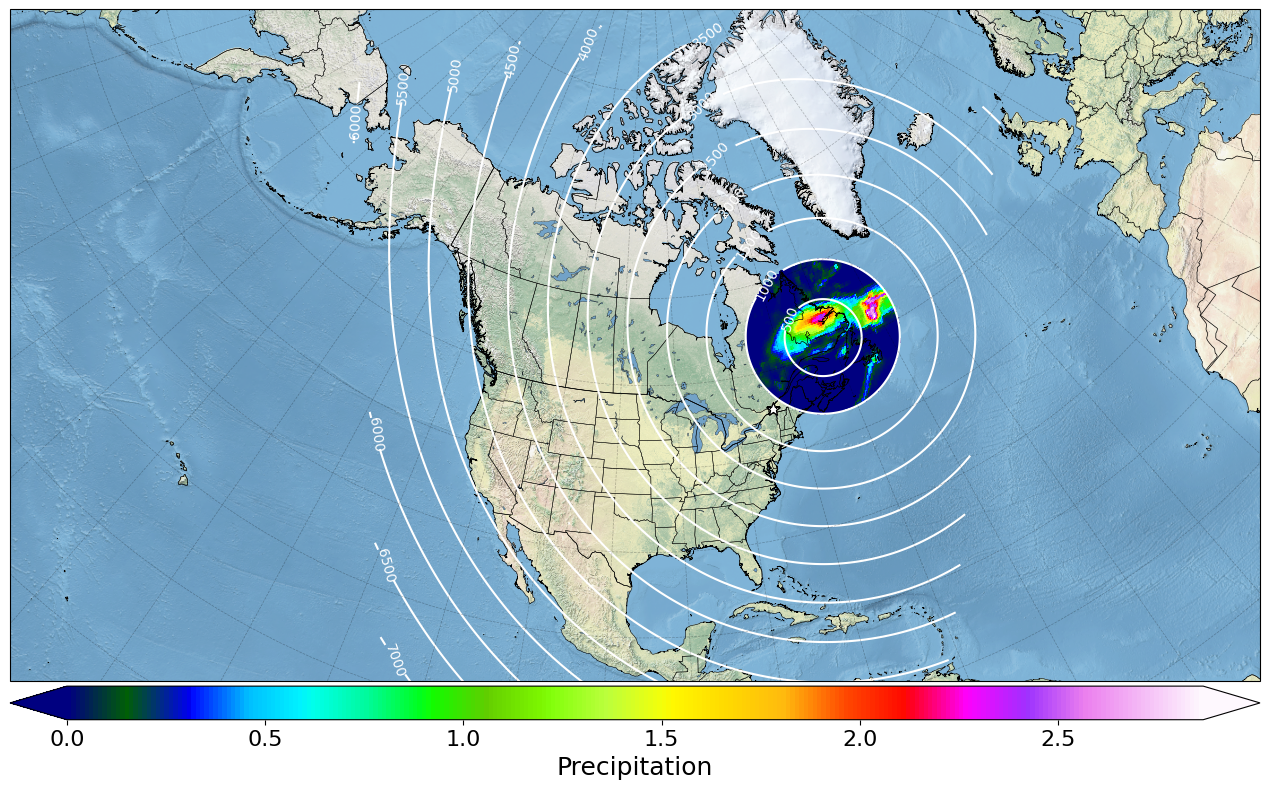

In [35]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(12.5,12.5), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-180, -15, 80, 15], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

mtl_lon, mtl_lat = -73.561668, 45.508888
ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=1, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_ncar')

time = 0

if extreme == True:

    quantile = 0.98
    
    if sim == 'ERA5':
        crs = ccrs.PlateCarree()
        sca = ax.pcolormesh(filtered_precip.longitude, filtered_precip.latitude,
                           filtered_precip.sel(quantile=quantile).isel(time=time).pr, cmap=cmap, transform=crs)
        sc = ax.contour(distances_precip.longitude, distances_precip.latitude, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip, levels=np.arange(0, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip.max(), 500), colors='white', transform=crs)

    else:
        pole_lon = ds_precip.rotated_pole.attrs['grid_north_pole_longitude']
        pole_lat = ds_precip.rotated_pole.attrs['grid_north_pole_latitude']
        crs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)
        sca = ax.pcolormesh(filtered_precip.rlon, filtered_precip.rlat,
                           filtered_precip.sel(quantile=quantile).isel(time=time).pr, cmap=cmap, transform=crs)
        sc = ax.contour(distances_precip.rlon, distances_precip.rlat, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip, levels=np.arange(0, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip.max(), 500), colors='white', transform=crs)

else:
    if sim == 'ERA5':
        crs = ccrs.PlateCarree()
        sca = ax.pcolormesh(precip_mask.longitude, precip_mask.latitude,
                           precip_mask.pr, cmap=cmap, transform=crs)
        sc = ax.contour(precip_mask.longitude, precip_mask.latitude, distances, levels=np.arange(0, distances.max(), 500), colors='white', transform=crs)

    else:
        pole_lon = ds_precip.rotated_pole.attrs['grid_north_pole_longitude']
        pole_lat = ds_precip.rotated_pole.attrs['grid_north_pole_latitude']
        crs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)
        #on ne plot que le dernier pas de temps car on save pas distances_precip pour ext=false
        sca = ax.pcolormesh(precip_mask.rlon, precip_mask.rlat,
                           precip_mask.pr, cmap=cmap, transform=crs)
        sc = ax.contour(precip_mask.rlon, precip_mask.rlat, distances, levels=np.arange(0, distances.max(), 500), colors='white', transform=crs)
    
ax.clabel(sc, inline=True, fontsize=10, fmt='%d')
cb = fig.colorbar(sca, cax=cax, orientation="horizontal", pad=0.02, extend='both', aspect=40)
cb.ax.tick_params(labelsize=16)
cb.set_label('Precipitation', fontsize=18)

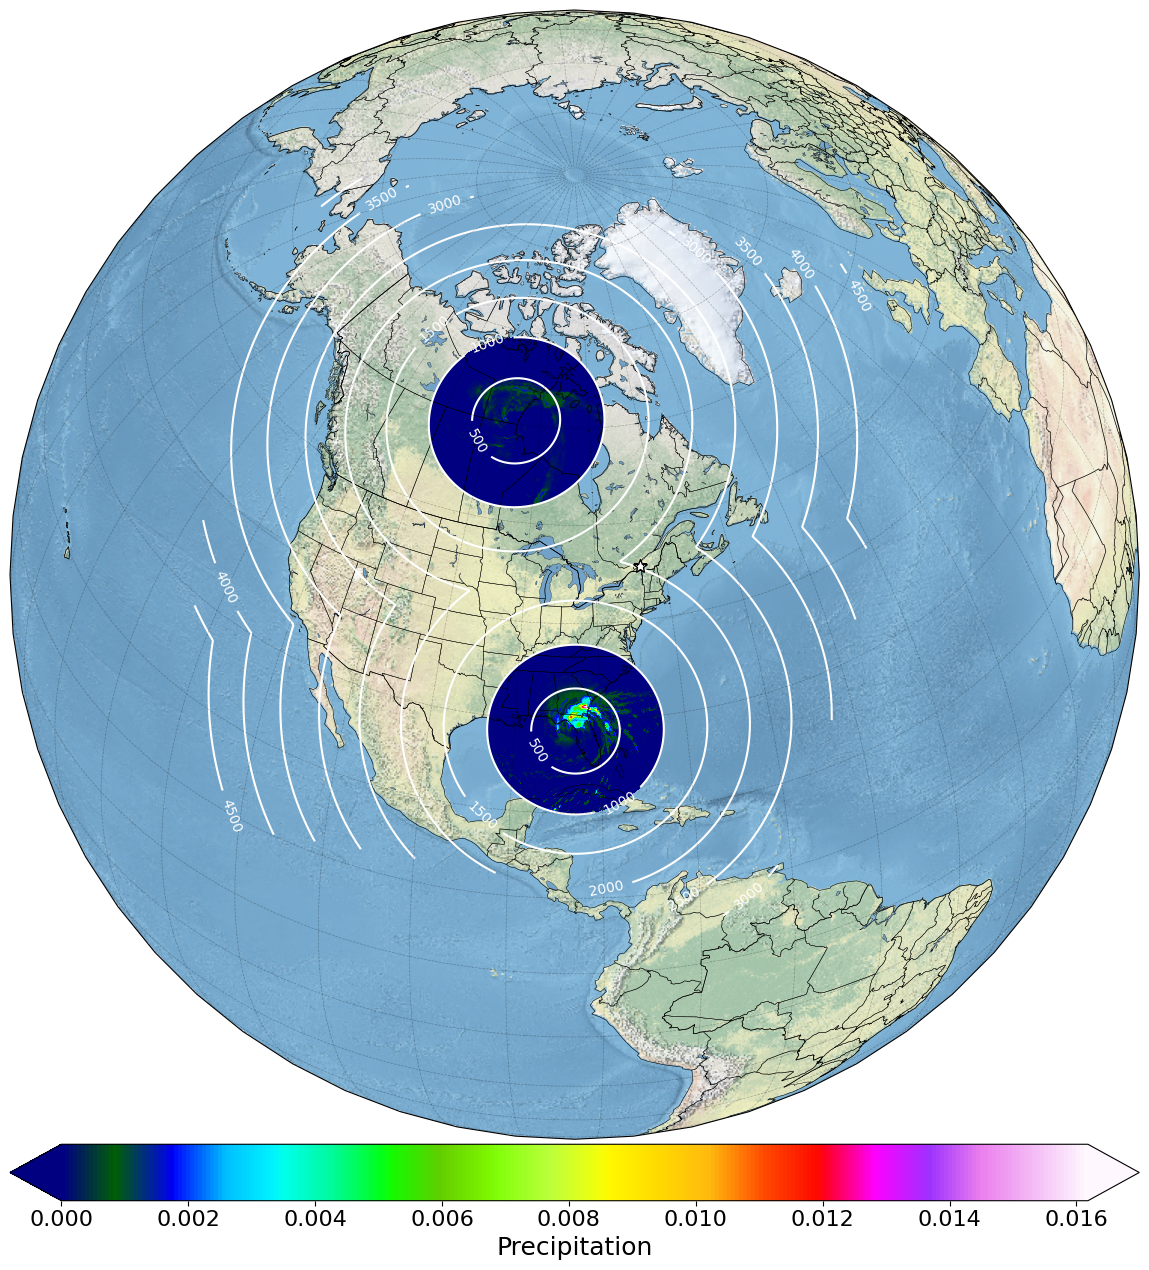

In [15]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(12.5,12.5), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

# ax.set_extent([-100, -55, 60, 35], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

mtl_lon, mtl_lat = -73.561668, 45.508888
ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=1, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_ncar')

time = 0

if extreme == True:

    quantile = 0.98
    
    if sim == 'ERA5':
        crs = ccrs.PlateCarree()
        sca = ax.pcolormesh(filtered_precip.longitude, filtered_precip.latitude,
                           filtered_precip.sel(quantile=quantile).isel(time=time).pr, cmap=cmap, transform=crs)
        sc = ax.contour(distances_precip.longitude, distances_precip.latitude, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip, levels=np.arange(0, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip.max(), 500), colors='white', transform=crs)

    else:
        pole_lon = ds_precip.rotated_pole.attrs['grid_north_pole_longitude']
        pole_lat = ds_precip.rotated_pole.attrs['grid_north_pole_latitude']
        crs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)
        sca = ax.pcolormesh(filtered_precip.rlon, filtered_precip.rlat,
                           filtered_precip.sel(quantile=quantile).isel(time=time).pr, cmap=cmap, transform=crs)
        sc = ax.contour(distances_precip.rlon, distances_precip.rlat, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip, levels=np.arange(0, distances_precip.sel(quantile=quantile).isel(time=time).distances_precip.max(), 500), colors='white', transform=crs)

else:
    if sim == 'ERA5':
        crs = ccrs.PlateCarree()
        sca = ax.pcolormesh(wind_mask.longitude, wind_mask.latitude,
                           wind_mask.surf_wind, cmap=cmap, transform=crs)
        sc = ax.contour(wind_mask.longitude, wind_mask.latitude, distances, levels=np.arange(0, distances.max(), 500), colors='white', transform=crs)

    else:
        pole_lon = ds_precip.rotated_pole.attrs['grid_north_pole_longitude']
        pole_lat = ds_precip.rotated_pole.attrs['grid_north_pole_latitude']
        crs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)
        #on ne plot que le dernier pas de temps car on save pas distances_precip pour ext=false
        sca = ax.pcolormesh(precip_mask.rlon, precip_mask.rlat,
                           precip_mask.pr, cmap=cmap, transform=crs)
        sc = ax.contour(precip_mask.rlon, precip_mask.rlat, distances, levels=np.arange(0, distances.max(), 500), colors='white', transform=crs)
    
ax.clabel(sc, inline=True, fontsize=10, fmt='%d')
cb = fig.colorbar(sca, cax=cax, orientation="horizontal", pad=0.02, extend='both', aspect=40)
cb.ax.tick_params(labelsize=16)
cb.set_label('Precipitation', fontsize=18)

## Test of the output file from the main script
Plot of a random day from an output file

In [3]:
filtered_precip = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR/1000km_storm/pr_era5_201911_1000km_1005hPa_extreme_storm.nc')
filtered_precip

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 720, latitude: 322, longitude: 732, quantile: 4)
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * time       (time) datetime64[ns] 6kB 2019-11-01 ... 2019-11-30T23:00:00
  * longitude  (longitude) float32 3kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * quantile   (quantile) float64 32B 0.98 0.99 0.995 0.999
Data variables:
    pr         (time, latitude, longitude, quantile) float64 5GB ...

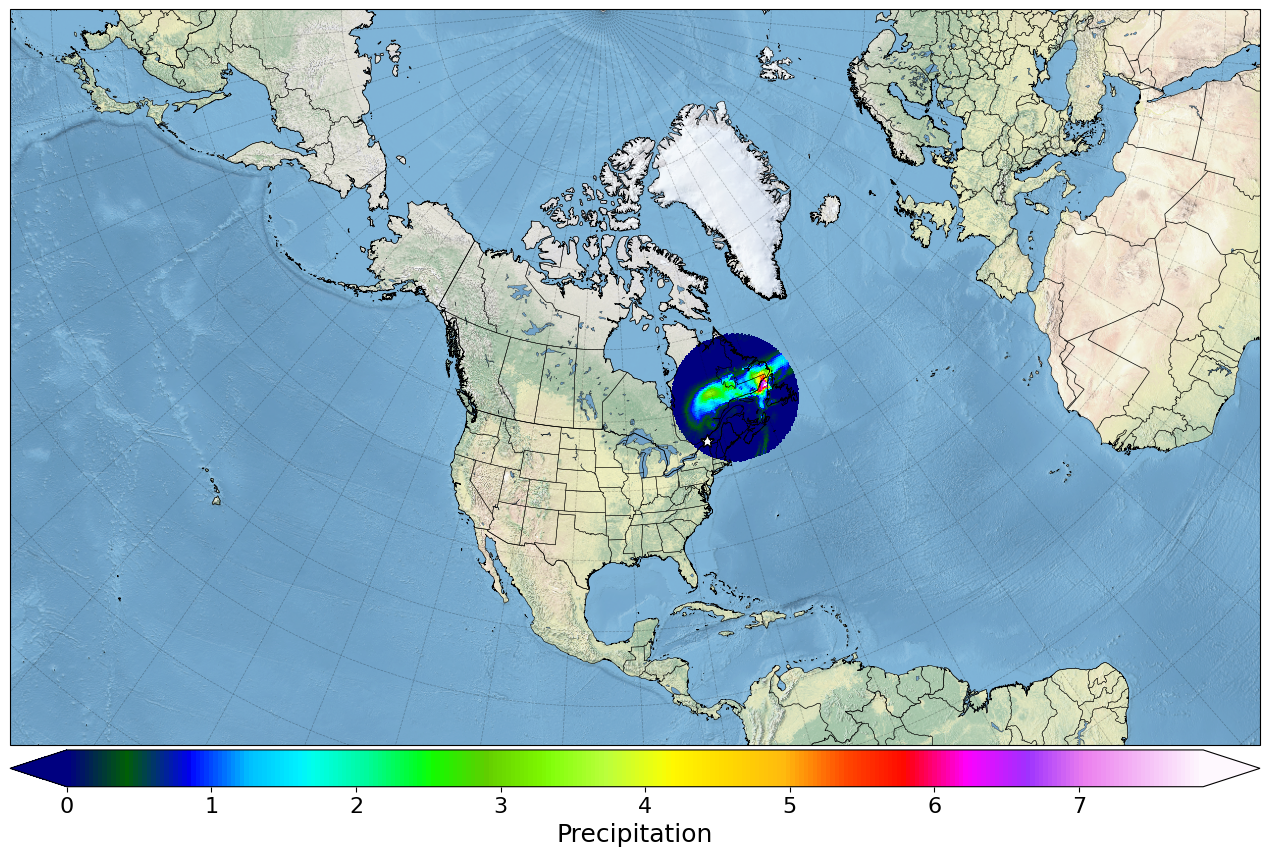

In [4]:
# pole_lon = ds_precip.rotated_pole.attrs['grid_north_pole_longitude']
# pole_lat = ds_precip.rotated_pole.attrs['grid_north_pole_latitude']

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(12.5,12.5), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-180, 5, 90, 5], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

mtl_lon, mtl_lat = -73.561668, 45.508888
ax.plot(mtl_lon, mtl_lat, marker='*', color='white', markersize=10, markeredgewidth=1, markeredgecolor='black', zorder=3, transform=ccrs.PlateCarree())

cmap = plt.get_cmap('gist_ncar')

crs = ccrs.PlateCarree()#ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)

sc = ax.pcolormesh(filtered_precip.longitude, filtered_precip.latitude,
                   filtered_precip.isel(time=19).sel(quantile=0.99).pr, cmap=cmap, transform=crs)

cb = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, extend='both', aspect=40)
cb.ax.tick_params(labelsize=16)
cb.set_label('Precipitation', fontsize=18)